## Когортный анализ и retention

Retention — не одна метрика, а **семейство конвенций**. Это самая важная представительница класса «сконструированных» метрик: именно она чаще всего оказывается North Star, и именно ее значение сильнее всего зависит от невидимых решений. Сегодня мы посчитаем удержание одного и того же продукта несколькими способами — и получим разные числа и разные выводы.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 14, 'axes.titlepad': 16,
    'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False,
})
rng = np.random.default_rng(11)

### Когортный анализ

**Когорта** — группа пользователей, объединённых временем общего стартового события (месяц регистрации, неделя первого заказа).   
**Когортный анализ** — наблюдение каждой такой группы во времени и сравнение групп между собой.

Любой агрегат по всей базе это смесь пользователей разного возраста и происхождения, поэтому средние, рассчитанные на всем объеме могут меняться по двум несвязанным причинам:
- изменилось поведение пользователей;
- изменился состав аудитории.

Когорты — способ развести эти причины: внутри когорты состав зафиксирован по построению.   
Вторая причина — продуктовая, пользователи разного «возраста» находятся на разных участках кривой удержания.

Retention — самая частая метрика на когортной основе, но не единственная: тем же приемом смотрят выручку и LTV когорты, время до первого заказа, эффект релизов.

### Четыре решения внутри retention

По образцу DAU с семинара событийной аналитики. Прежде чем назвать число «retention», кто-то решил:

| Решение | Варианты | Что меняет |
|---|---|---|
| **1. Стартовое событие** | регистрация / первый заказ / активация | от какой точки считается «день 0», и кто вообще попадает в когорту |
| **2. Возвратное событие** | любая активность / целевое действие | «зашел в приложение» и «сделал заказ» — два разных retention |
| **3. Окно** | Day N (точечный) / Week(Period) N / Rolling / bracket | одна и та же когорта, учтенная разными способами, дает отличающиеся числа |
| **4. Идентичность** | device_id / user_id / политика склейки | мультиаккаунты и переустановки занижают retention: человек «ушел» одним идентификатором и «пришел» другим (семинар событийной аналитики) |

Прежде чем сравнивать retention двух продуктов или свой с бенчмарком — сверьте точки принятия решения. Чаще всего различаются они, а не удержание.

Второе следствие, ради которого существует когортный анализ: аудитория в любой момент — смесь пользователей разного возраста и происхождения. Агрегированный retention двигается от изменения структуры состава, даже если поведение каждого сегмента неизменно. Когорта — единственный честный способ сравнивать удержание во времени.

### Данные

Сервис доставки продуктов: таблица заказов и таблица регистраций с каналом привлечения. Данные синтетические, ~8 месяцев.

In [2]:
def generate_retention_data(seed=11):
    rng = np.random.default_rng(seed)
    t0 = pd.Timestamp('2026-01-01')
    
    months = 8
    regs, orders = [], []
    uid = 0
    
    for m in range(months):
        m_start = t0 + pd.DateOffset(months=m)
        paid_share = [0.30, 0.30, 0.32, 0.31, 0.33, 0.35, 0.52, 0.68][m]
        
        for _ in range(4200):
            uid += 1
            u = f'u_{uid:06d}'
            channel = 'paid' if rng.random() < paid_share else 'organic'
            reg_ts = m_start + pd.Timedelta(days=float(rng.uniform(0, 28)), hours=float(rng.uniform(8, 23)))
            regs.append((u, reg_ts, channel))
            
            if rng.random() < (0.72 if channel == 'organic' else 0.62):
                first_delay = float(rng.exponential(3))
                life = float(rng.exponential(75 if channel == 'organic' else 15))
                d = first_delay
                
                while d <= first_delay + life:
                    ts = reg_ts + pd.Timedelta(days=d)
                    
                    if ts > pd.Timestamp('2026-08-31'):
                        break
                    orders.append((u, ts))
                    d += max(1, rng.normal(9, 4))
    
    df_registrations = pd.DataFrame(regs, columns=['user_id', 'created_at', 'channel'])
    df_orders = pd.DataFrame(orders, columns=['user_id', 'created_at'])
    
    return df_orders.sort_values('created_at').reset_index(drop=True), \
           df_registrations.sort_values('created_at').reset_index(drop=True)

In [3]:
df_orders, df_registrations = generate_retention_data()

print(f'Заказов: {len(df_orders):,};  регистраций: {len(df_registrations):,};  '
      f'период: {df_orders.created_at.min().date()} — {df_orders.created_at.max().date()}')

Заказов: 118,165;  регистраций: 33,600;  период: 2026-01-01 — 2026-08-30


In [4]:
df_orders.head(3)

,user_id,created_at
0,u_003971,2026-01-01 13:17:22.011135222
1,u_003104,2026-01-01 18:15:01.982817037
2,u_000109,2026-01-02 00:43:48.320914869


In [5]:
df_registrations.head(3)

,user_id,created_at,channel
0,u_001637,2026-01-01 10:01:11.965646617,organic
1,u_002660,2026-01-01 11:42:42.185597471,organic
2,u_003971,2026-01-01 12:42:18.438231409,organic


### Решение 1: стартовое событие

Retention можно рассчитывать от разных действий. Можно проверять активность со дня регистрации, а можно смотреть возвратность в целевое действие после того, как пользователь совершил его первый раз.

Подход выбирается от типа продукта и задачи: для соцсетей и игр подойдёт любая активность; для продуктов с явным целевым действием (покупка, заказ, поездка) днем 0 чаще берут дату первого заказа. Мы работаем с доставкой продуктов — **день 0 = дата первого заказа, возвратность = повторные заказы** (Решение 2). 

In [6]:
df_orders_w_reg = df_orders.merge(df_registrations.rename(columns={'created_at': 'registration_date'}),
                                  on='user_id', how='left')

df_first_order_date = df_orders_w_reg[~df_orders_w_reg['registration_date'].isna()] \
    .groupby(['user_id', 'registration_date'], as_index=False) \
    .created_at.min().rename(columns={'created_at': 'first_order_date'})

df_new_users_orders = df_orders.merge(df_first_order_date, on=['user_id'], how='inner')
df_new_users_orders.head(3)

,user_id,created_at,registration_date,first_order_date
0,u_003971,2026-01-01 13:17:22.011135222,2026-01-01 12:42:18.438231409,2026-01-01 13:17:22.011135222
1,u_003104,2026-01-01 18:15:01.982817037,2026-01-01 17:20:35.769266737,2026-01-01 18:15:01.982817037
2,u_000109,2026-01-02 00:43:48.320914869,2026-01-02 00:39:40.367473716,2026-01-02 00:43:48.320914869


#### Цена стартового события

Посчитайте долю зарегистрированных в январе–июне, которые вернулись за заказом в **дни 1–30**, двумя способами: (а) день 0 = **регистрация**; (б) день 0 = **первый заказ**.

In [7]:
base = df_registrations[df_registrations.created_at < '2026-07-01']

orders = df_orders.merge(base.rename(columns={'created_at': 'reg'}), on='user_id', how='inner')
orders['dd'] = (orders.created_at - orders.reg).dt.days
from_reg = orders[(orders.dd >= 1) & (orders.dd <= 30)].user_id.nunique() / base.user_id.nunique()

fo = df_new_users_orders[df_new_users_orders.first_order_date < '2026-07-01']
fo = fo.assign(dd=(fo.created_at - fo.first_order_date).dt.days)
cohort_b = fo.user_id.nunique()
from_first = fo[(fo.dd >= 1) & (fo.dd <= 30)].user_id.nunique() / cohort_b

print(f'(а) От регистрации: вернулись в дни 1–30 — {from_reg:.1%} от всех зарегистрированных')
print(f'(б) От первого заказа: вернулись в дни 1–30 — {from_first:.1%} от сделавших первый заказ')

(а) От регистрации: вернулись в дни 1–30 — 64.7% от всех зарегистрированных
(б) От первого заказа: вернулись в дни 1–30 — 79.9% от сделавших первый заказ


Эти два retention отвечают на разные вопросы: (а) — про весь путь с активацией, (б) — про ценность продукта для попробовавших.

### Решение 3: Day N Retention

Считаем долю пользователей, совершивших заказы **на день N** после первого заказа (день первого заказа — нулевой).

Такой расчет подходит продуктам с высокой частотой использования — стриминги, соцсети, игры, быстрая FMCG-доставка: тем, где целевое состояние — ежедневное использование.

Так как данных немного, агрегируем когорты по месяцам — но в зависимости от задачи агрегация может быть любой (держа в голове, что когорты внутри периода могут вести себя по-разному).

In [8]:
df_new_users_orders['days_since_first'] = (df_new_users_orders['created_at'] - df_new_users_orders['first_order_date']).dt.days
df_new_users_orders['month'] = df_new_users_orders['first_order_date'].dt.to_period('M').dt.to_timestamp()

In [9]:
df_orders.groupby('user_id').created_at.diff().median()

Timedelta('8 days 15:04:51.261134652')

In [10]:
df_retained_daily = df_new_users_orders.groupby(['month', 'days_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique')).sort_values(by=['month', 'days_since_first'])

df_retention_day_n = df_retained_daily \
    .merge(df_retained_daily[df_retained_daily['days_since_first'] == 0][['month', 'retained_users']] \
    .rename(columns={'retained_users': 'base'}), on=['month'], how='left')

df_retention_day_n['retention_rate'] = df_retention_day_n.retained_users / df_retention_day_n.base

In [11]:
df_retention_day_n_pivoted = df_retention_day_n[df_retention_day_n['days_since_first'].isin([7, 14, 30])] \
    .pivot(index='month', columns='days_since_first', values='retention_rate') \
    .rename(columns=lambda x: f'D_{int(x)}') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')
df_retention_day_n_pivoted.head(6)

,month,D_7,D_14,D_30
0,2026-01-01,0.083242,0.070156,0.053799
1,2026-02-01,0.094333,0.080164,0.060030
2,2026-03-01,0.080039,0.076474,0.054115
3,2026-04-01,0.089537,0.076194,0.050211
4,2026-05-01,0.082442,0.085202,0.057606
5,2026-06-01,0.091135,0.078723,0.043617


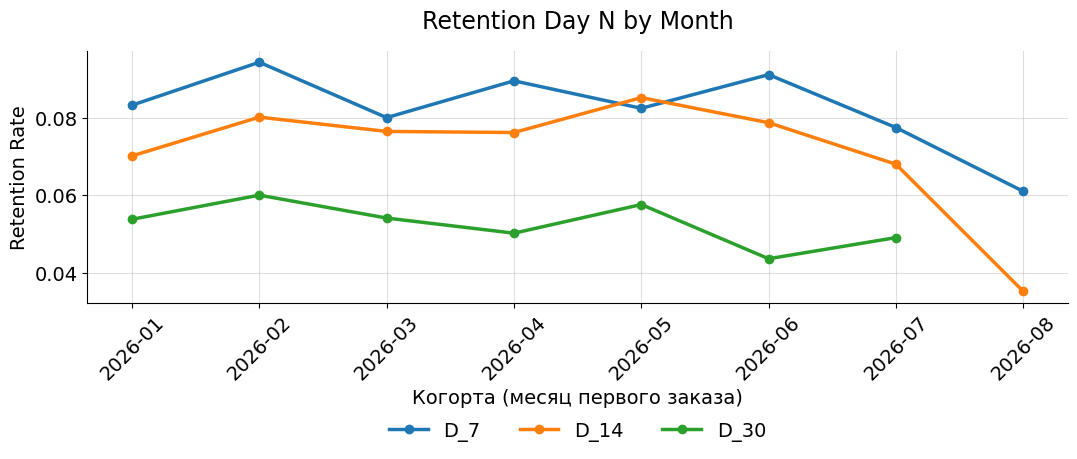

In [12]:
def get_retention_plot(df, x, y_list, time):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for col in y_list:
        ax.plot(df[x].dt.strftime('%Y-%m'), df[col], lw=2.5, marker='o', label=col)
    ax.set_title(f'Retention {time}')
    ax.set_xlabel('Когорта (месяц первого заказа)')
    ax.set_ylabel('Retention Rate')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=len(y_list), frameon=False)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

get_retention_plot(df_retention_day_n_pivoted, 'month', ['D_7', 'D_14', 'D_30'], 'Day N by Month')

Обратите внимание на послений период: день 30 последней когорты пока не существует — не прошло 30 дней. Незавершенные когорты нельзя сравнивать с завершенными. 

И заметьте общий уровень: точечные дневные значения для сервиса с заказом раз в ~9 дней — единицы процентов. Метрика работает, но почти ничего не говорит: не тот инструмент для этой частоты.

### Retention Curve

По оси X — дни с момента первого действия, по оси Y — доля удержанных к этому дню. Кривая показывает, через какое время удержание выходит на **плато**: пользователи, дошедшие до него, привыкли и остаются.

Кривую можно строить для когорты дня, недели, месяца — здесь работаем со всем датасетом сразу ради объема данных.

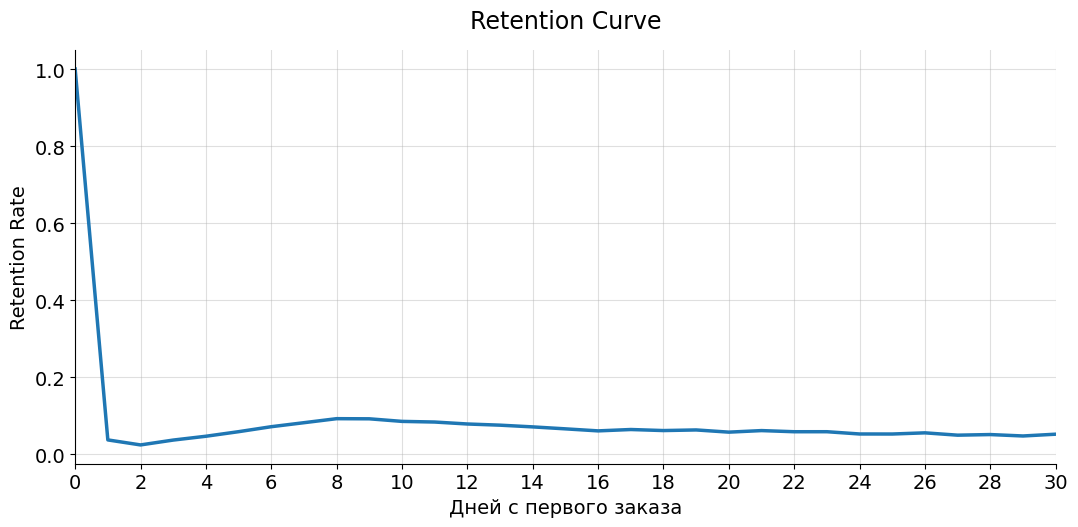

In [13]:
df_retention_grouped = df_retention_day_n.groupby(['days_since_first'], as_index=False) \
    .agg(retained_users=('retained_users', 'sum'),
         base=('base', 'sum'))
df_retention_grouped['retention_rate'] = df_retention_grouped.retained_users / df_retention_grouped.base
df_retention_grouped_30 = df_retention_grouped[df_retention_grouped['days_since_first'] <= 30]

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(df_retention_grouped_30['days_since_first'], df_retention_grouped_30['retention_rate'], lw=2.5)
ax.set_title('Retention Curve')
ax.set_xlabel('Дней с первого заказа')
ax.set_ylabel('Retention Rate')
ax.set_xticks(np.arange(0, 31, 2))
ax.margins(x=0)
ax.grid(True, alpha=0.4)
plt.tight_layout() 
plt.show()

**Плато — экономический сигнал.** Кривая, выходящая на плато, означает, что у продукта есть ядро, для которого он стал привычкой. Высота плато × частота использования ~ будущий LTV — деньги, которые ядро принесет за жизнь. Если кривая, сползает к нулю без плато — значит пользователи не остаются в продукте, и сначала чинить удержание, а потом лить трафик (логика OMTM из Лекции 2).

### Решение 3: Week N (Period N) Retention

Для продуктов без ежедневного использования Day N бесполезен: выделить конкретный день возврата сложно, и точечные значения сильно занижают реальную ценность — заметная часть пользователей вернулась на пару дней раньше или позже. Считаем возвратность в течение **недель** (или месяцев — для совсем редких).

**Конвенция нумерации**: день 0 — отдельно (Week 0 = только день первого заказа), дальше Week 1 = дни 1–7, Week 2 = дни 8–14, Week 4 = дни 22–28. Это одна из двух распространенных нумераций (можно также считать недели с нуля: Week 4 = дни 28–34).   
**Нумерация недель — ещё одна спрятанная конвенция**: сверяйте границы, а не имена.

In [14]:
df_new_users_orders['weeks_since_first'] = np.where(df_new_users_orders['days_since_first'] == 0,
                                                    0, ((df_new_users_orders['days_since_first'] - 1) // 7) + 1)

df_retained_by_week = df_new_users_orders.groupby(['month', 'weeks_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique')).sort_values(by=['month', 'weeks_since_first'])

df_retention_week_n = df_retained_by_week \
    .merge(df_retained_by_week[df_retained_by_week['weeks_since_first'] == 0][['month', 'retained_users']] \
    .rename(columns={'retained_users': 'base'}), on=['month'], how='left')

df_retention_week_n['retention_rate'] = df_retention_week_n.retained_users / df_retention_week_n.base

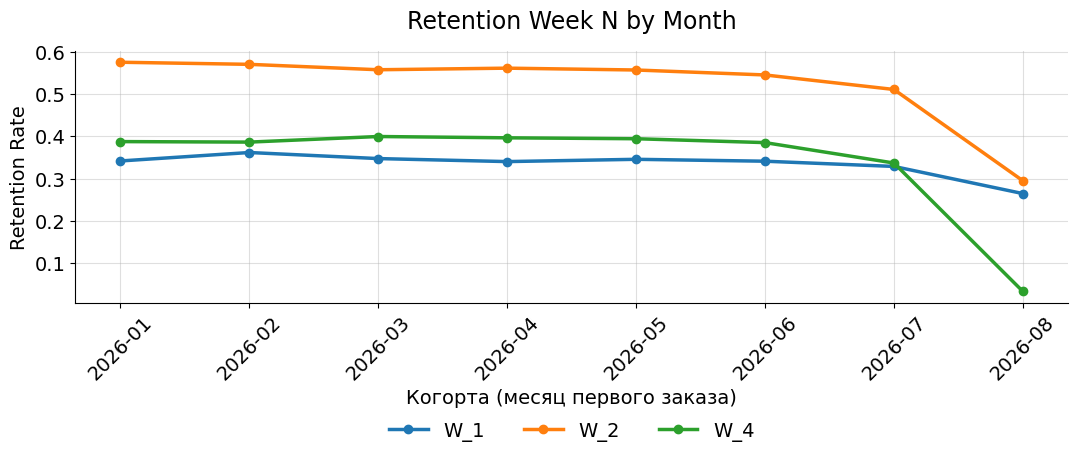

In [15]:
df_retention_week_n_pivoted = df_retention_week_n[df_retention_week_n['weeks_since_first'].isin([1, 2, 4])] \
    .pivot(index='month', columns='weeks_since_first', values='retention_rate') \
    .rename(columns=lambda x: f'W_{int(x)}') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')

get_retention_plot(df_retention_week_n_pivoted, 'month', ['W_1', 'W_2', 'W_4'], 'Week N by Month')

При недельном расчете фактическое удержание оказалось в ~8 раз выше, чем при дневной оценке, при том, что пользователи те же и поведение то же. Изменилась конвенция окна.

### Решение 3: Rolling Retention

Скользящий расчет: учитываем действия **не только в выбранный день/период, но и в любые даты после**. В Day 7 Rolling попадут вернувшиеся на 7-й день *или позже*.

Скользящая формула **систематически завышает** значения относительно фиксированного окна — подчеркивайте выбранный подход в вашей аналитике. При этом для низкочастотных продуктов Rolling может быть самым честным вариантом: магазину крупной бытовой техники сложно назвать даже месяц потенциального возврата, а отслеживать удержание все равно нужно.

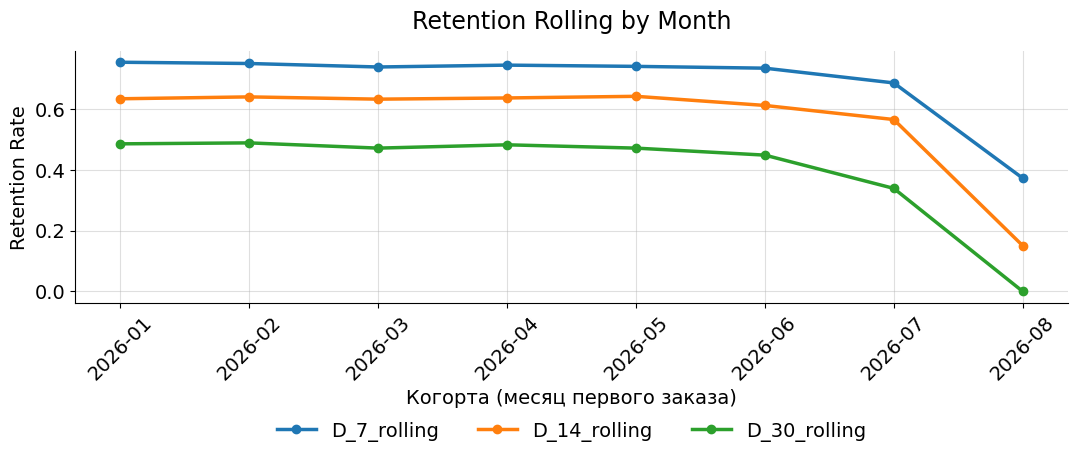

In [16]:
df_new_users_max_diff = df_new_users_orders.groupby(['month', 'first_order_date', 'user_id'], as_index=False) \
    .days_since_first.max()

df_retained_by_max_diff = df_new_users_max_diff.groupby(['month', 'days_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique'))

df_retained_by_max_diff_pivoted = df_retained_by_max_diff \
    .pivot(index='month', columns='days_since_first', values='retained_users') \
    .fillna(0).astype(int)

df_retained_rolling = df_retained_by_max_diff_pivoted.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1]

df_retained_rolling_30 = df_retained_rolling.loc[:, 0:30]
df_retention_rolling_30 = df_retained_rolling_30.div(df_retained_rolling_30[0], axis=0)

df_retention_rolling_30 = df_retention_rolling_30 \
    .rename(columns=lambda x: f'D_{int(x)}_rolling') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')

get_retention_plot(df_retention_rolling_30, 'month', ['D_7_rolling', 'D_14_rolling', 'D_30_rolling'], 'Rolling by Month')

Технический нюанс Rolling: возраст когорты здесь влияет сильнее других подходов — «вернется позже» у свежих когорт ещё не успело случиться, поэтому последние месяцы всегда выглядят хуже и **досчитываются со временем**. Rolling-отчет за вчерашний месяц — не финальное число.

### Решение 3: Bracket (Interval) Retention

Обобщение Week N: календарь жизни пользователя режется не на равные недели,
а на **настраиваемые интервалы-корзины**, обычно расширяющиеся: день 0 | дни 1–3 | 4–7 | 8–14 | 15–30.

Логика расширения — под естественное затухание частоты: в начале жизни важна каждая пара дней (онбординг, первый возврат), дальше ритм затухает, и узкие окна начинают ловить шум календаря вместо поведения. Week N — частный случай bracket с равными интервалами. Отличие от Rolling принципиально: bracket — фиксированные непересекающиеся окна, Rolling — накопительное «в день N или позже».

Сильная сторона — гибкость под ритм продукта. Слабая — сложность: границы корзин — еще несколько спрятанных решений, и сравнивать bracket-числа между продуктами или системами аналитики почти невозможно — у каждого свои трешхолды. 

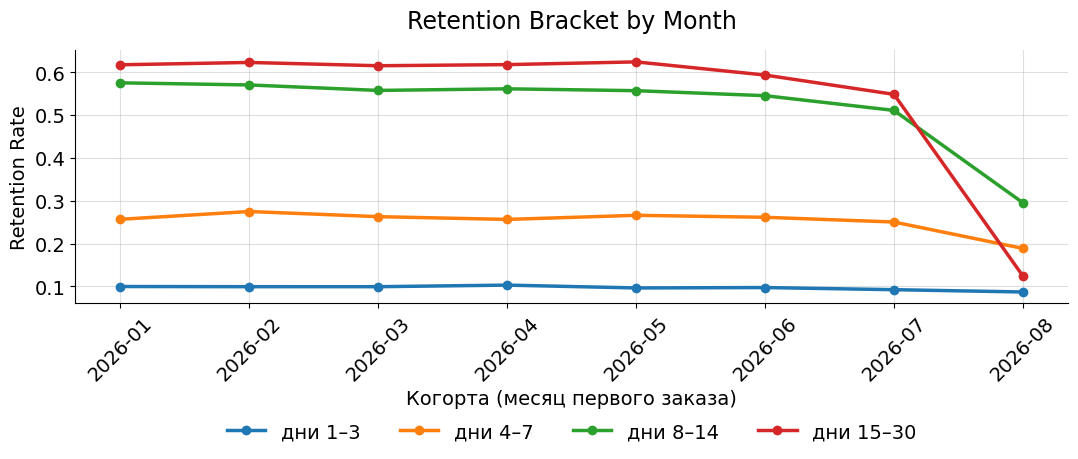

In [17]:
bracket_bins   = [-0.5, 0.5, 3.5, 7.5, 14.5, 30.5]
bracket_labels = ['день 0', 'дни 1–3', 'дни 4–7', 'дни 8–14', 'дни 15–30']

df_b = df_new_users_orders[df_new_users_orders.days_since_first <= 30].copy()
df_b['bracket'] = pd.cut(df_b.days_since_first, bins=bracket_bins, labels=bracket_labels)

df_retained_bracket = df_b.groupby(['month', 'bracket'], as_index=False, observed=True) \
    .agg(retained_users=('user_id', 'nunique'))

df_retention_bracket = df_retained_bracket \
    .merge(df_retained_bracket[df_retained_bracket.bracket == 'день 0'][['month', 'retained_users']]
           .rename(columns={'retained_users': 'base'}), on='month', how='left')
df_retention_bracket['retention_rate'] = df_retention_bracket.retained_users / df_retention_bracket.base

df_retention_bracket_pivoted = df_retention_bracket \
    .pivot(index='month', columns='bracket', values='retention_rate') \
    .reset_index().rename_axis(index=None, columns=None).sort_values('month')

get_retention_plot(df_retention_bracket_pivoted, 'month',
                   ['дни 1–3', 'дни 4–7', 'дни 8–14', 'дни 15–30'], 'Bracket by Month')

**Корзины не сравнимы между собой**: «дни 15–30» шире «дней 1–3», у пользователя в 5 раз выше шанс попасть в широкое окно.   
Сравнивать можно одну корзину между когортами (по горизонтали графика).

### Одна когорта — четыре числа: методы лоб в лоб

Главная демонстрация семинара. Возьмём **одну** когорту (первый заказ в марте) и ответим на **один** вопрос — «удерживаются ли пользователи через месяц?» — четырьмя легальными конвенциями.

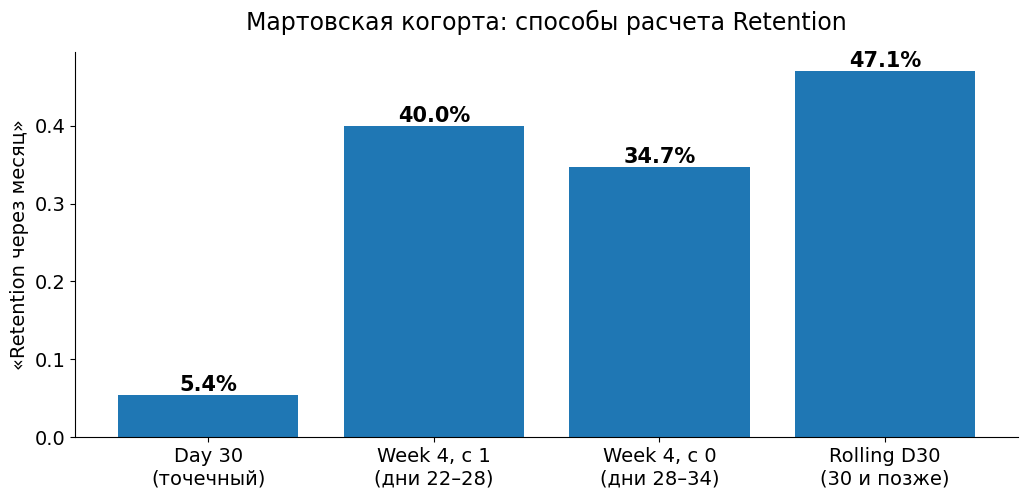

In [22]:
mar = df_new_users_orders[df_new_users_orders.month == '2026-03-01']
base_mar = mar.user_id.nunique()

d30_point = mar[mar.days_since_first == 30].user_id.nunique() / base_mar
w4_1based = mar[(mar.days_since_first >= 22) & (mar.days_since_first <= 28)].user_id.nunique() / base_mar
w4_0based = mar[(mar.days_since_first >= 28) & (mar.days_since_first <= 34)].user_id.nunique() / base_mar
roll_d30  = mar[mar.days_since_first >= 30].user_id.nunique() / base_mar

methods = {
    'Day 30 (точечный)':                 d30_point,
    'Week 4, нумерация с 1 (дни 22–28)': w4_1based,
    'Week 4, нумерация с 0 (дни 28–34)': w4_0based,
    'Rolling D30 (30 и позже)':          roll_d30,
}

fig, ax = plt.subplots(figsize=(10.5, 5.2))

labels = ['Day 30\n(точечный)',
          'Week 4, с 1\n(дни 22–28)',
          'Week 4, с 0\n(дни 28–34)',
          'Rolling D30\n(30 и позже)']

bars = ax.bar(labels, list(methods.values()))
ax.bar_label(bars, fmt='{:.1%}', fontsize=15, fontweight='bold')
ax.set_title('Мартовская когорта: способы расчета Retention')
ax.set_ylabel('«Retention через месяц»')

plt.tight_layout()
plt.show()

Пользователи одни и те же. Поведение одно и то же. Отличаются только определения.   
**Вывод**: при выводе retention нужно указывать конвенцию: стартовое событие + возвратное событие + окно + нумерация.

Как выбирать окно — от частоты продукта:

| Естественная частота продукта | Правильная конвенция |
|---|---|
| Ежедневная (соцсети, игры, мессенджеры) | Day N |
| Еженедельная (доставка продуктов, фитнес, маркетплейсы) | Week N |
| Ежемесячная (банкинг, услуги) | Month N |
| Редкая/эпизодическая (техника, путешествия, недвижимость) | Rolling |

Правило: окно должно вмещать **естественный цикл использования** — иначе вы измеряете не удержание, а несовпадение календаря с ритмом продукта.

### Когортный heatmap: главный отчет когортного анализа

Все, что мы считали, складывается в один артефакт — **когортный треугольник**: строки — когорты (месяц первого заказа), столбцы — недели с первого заказа, в ячейках — retention.

Три направления чтения:
- **вправо по строке** — жизнь одной когорты: где кривая выходит на плато;
- **вниз по столбцу** — качество когорт со временем: продукт для новичков улучшается или деградирует;
- **по диагонали** — календарные события: релиз, акция или поломка трекинга бьют по **всем** когортам в одну календарную дату — на треугольнике это диагональная полоса.

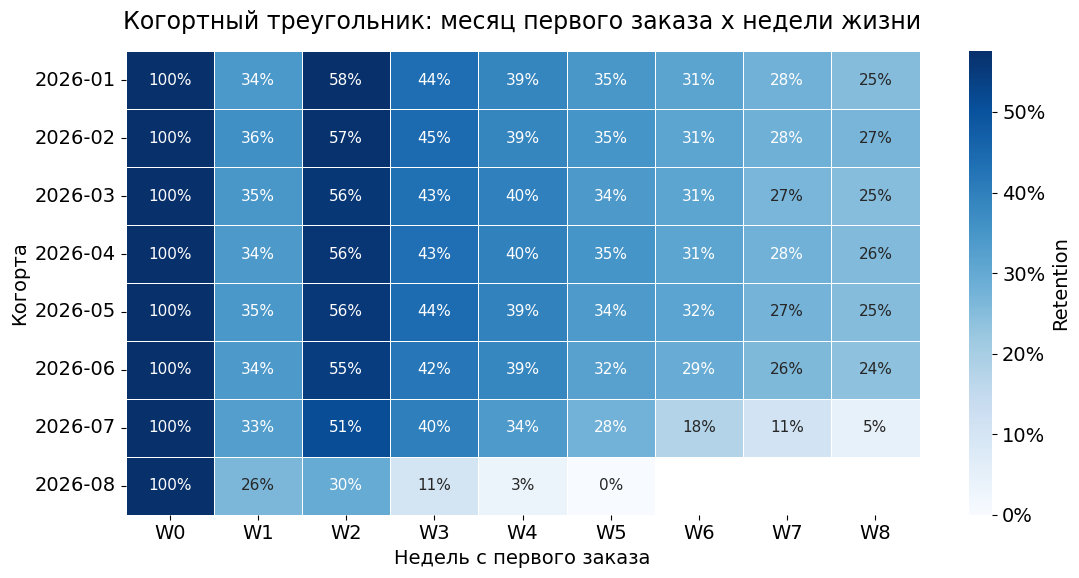

In [19]:
hm = df_retention_week_n.pivot(index='month', columns='weeks_since_first', values='retention_rate')
hm = hm.loc[:, 0:8]
hm.index = hm.index.strftime('%Y-%m')
hm.columns = [f'W{c}' for c in hm.columns]

fig, ax = plt.subplots(figsize=(11.5, 6))

sns.heatmap(hm, annot=True, fmt='.0%', cmap='Blues',
            vmin=0, vmax=np.nanmax(hm.values[:, 1:]),
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Retention', 'format': lambda x, _: f'{x:.0%}'},
            annot_kws={'fontsize': 11}, ax=ax)

ax.set_title('Когортный треугольник: месяц первого заказа x недели жизни')
ax.set_xlabel('Недель с первого заказа')
ax.set_ylabel('Когорта')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### Чтение треугольника

Ответьте по heatmap:
1. На какой неделе жизни когорты выходят на плато?
2. Что происходит с качеством когорт сверху вниз — и с какого месяца?
3. Видите ли вы диагональные полосы (календарные события)?

### Финальный кейс: Retention упал — продукт стал хуже?

Сообщение от PM:
> Смотрю на когортный отчёт: W2-retention июльских и августовских когорт просел на 15–20% к весеннему уровню. Мы что-то сломали в продукте летом?

**Расследование**:
1. Подтвердите: W2 retention по когортам — динамика.
2. Вспомните семинар 1: если агрегат упал — проверьте состав. Какие срезы есть в данных?
3. Посчитайте W2 retention по когортам внутри каждого канала привлечения.
4. Посчитайте долю каналов в когортах по месяцам.

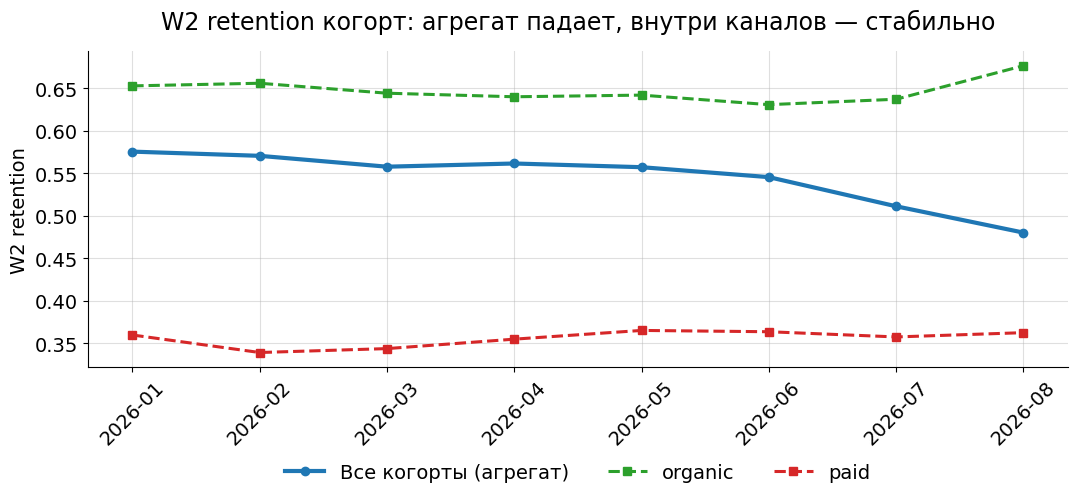

In [20]:
dfo = df_new_users_orders.merge(df_registrations[['user_id', 'channel']], on='user_id', how='left')

def w2_by(df, by=None):
    df = df[df.first_order_date <= '2026-08-16']
    keys = ['month'] + ([by] if by else [])
    base = df[df.weeks_since_first == 0].groupby(keys).user_id.nunique().rename('base')
    w2 = df[df.weeks_since_first == 2].groupby(keys).user_id.nunique().rename('w2')
    return (pd.concat([base, w2], axis=1).assign(rate=lambda x: x.w2 / x.base)).reset_index()

overall = w2_by(dfo)
by_ch = w2_by(dfo, 'channel')

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(overall.month.dt.strftime('%Y-%m'), overall.rate, lw=3, color='#1f77b4', marker='o', label='Все когорты (агрегат)')
for ch, c in [('organic', '#2ca02c'), ('paid', '#d62728')]:
    sub = by_ch[by_ch.channel == ch]
    ax.plot(sub.month.dt.strftime('%Y-%m'), sub.rate, lw=2.2, ls='--', marker='s', color=c, label=f'{ch}')

ax.set_title('W2 retention когорт: агрегат падает, внутри каналов — стабильно')
ax.set_ylabel('W2 retention'); ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

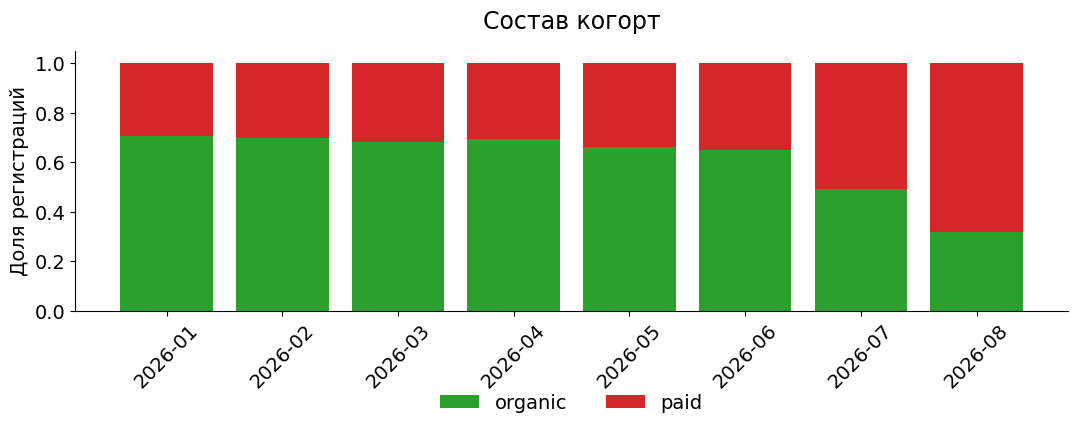

In [21]:
mix = df_registrations.assign(month=df_registrations.created_at.dt.to_period('M').dt.to_timestamp()) \
        .groupby('month').channel.value_counts(normalize=True).unstack()

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.bar(mix.index.strftime('%Y-%m'), mix['organic'], label='organic', color='#2ca02c')
ax.bar(mix.index.strftime('%Y-%m'), mix['paid'], bottom=mix['organic'], label='paid', color='#d62728')
ax.set_title('Состав когорт')
ax.set_ylabel('Доля регистраций'); ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Вывод**: продукт летом не ломался — внутри каждого канала привлечения W2-retention когорт стабилен весь год. Падение агрегата — сдвиг состава: с июля доля платного трафика в новых когортах выросла с ~30% до ~70%, а paid-пользователи всегда удерживались хуже органики.

**Источники:** 
- GoPractice — [Retention](https://gopractice.ru/product/retention/), [N-day и Rolling](https://gopractice.ru/product/nday-retention-rollling-retention/)
- Amplitude — [Mastering Retention](https://amplitude.com/books/mastering-retention)
- Mixpanel — [Custom Retention Brackets](https://docs.mixpanel.com/docs/reports/retention#custom-retention-brackets)